# HVM Fit Demo: Synthetic Rheology Data

This notebook demonstrates HVM fitting on a positive-control rheology dataset generated from `HVMLocal`. The later experimental-data notebooks are useful for model/data suitability checks; this notebook is the compact case where the fitted HVM responses should overlap the raw data.

In [1]:
from pathlib import Path
import sys

import matplotlib.pyplot as plt
import numpy as np

PROJECT_ROOT = Path.cwd().parents[1] if Path.cwd().name == "hvm" else Path.cwd()
EXAMPLES_DIR = PROJECT_ROOT / "examples"
if str(EXAMPLES_DIR) not in sys.path:
    sys.path.insert(0, str(EXAMPLES_DIR))

from utils.hvm_demo_fit import run_hvm_demo_fits

## Fit HVM Responses

The helper generates noisy synthetic data for flow curve, relaxation, creep, and startup protocols, then fits a fresh `HVMLocal` instance for each protocol.

In [2]:
results = run_hvm_demo_fits(noise_level=0.01)

for protocol, result in results.items():
    print(f"{protocol:12s} R² = {result.r_squared:.6f}")

INFO:nlsq.least_squares:Starting least squares optimization method=trf | n_params=8 | loss=linear | ftol=1.0000e-06 | xtol=1.0000e-06 | gtol=1.0000e-06


PERFORMANCE:nlsq.least_squares:Timer: optimization elapsed=1.347105s


INFO:nlsq.least_squares:Convergence reason=Both `ftol` and `xtol` termination conditions are satisfied. | iterations=3 | final_cost=2.0262e-04 | elapsed=1.347s | final_gradient_norm=3.1604e-08


INFO:nlsq.least_squares:Starting least squares optimization method=trf | n_params=8 | loss=linear | ftol=1.0000e-06 | xtol=1.0000e-06 | gtol=1.0000e-06


PERFORMANCE:nlsq.least_squares:Timer: optimization elapsed=0.672016s


...

INFO:nlsq.least_squares:Convergence reason=`xtol` termination condition is satisfied. | iterations=5 | final_cost=0.0437 | elapsed=0.160s | final_gradient_norm=7.1034e+04


INFO:nlsq.least_squares:Starting least squares optimization method=trf | n_params=8 | loss=linear | ftol=1.0000e-06 | xtol=1.0000e-06 | gtol=1.0000e-06


PERFORMANCE:nlsq.least_squares:Timer: optimization elapsed=0.163708s


INFO:nlsq.least_squares:Convergence reason=`xtol` termination condition is satisfied. | iterations=5 | final_cost=0.5162 | elapsed=0.164s | final_gradient_norm=8.8246e+05


flow_curve   R² = 0.999991
relaxation   R² = 0.999899
creep        R² = 0.999831
startup      R² = 0.991022


## Overlay Raw Data and Fitted HVM Predictions

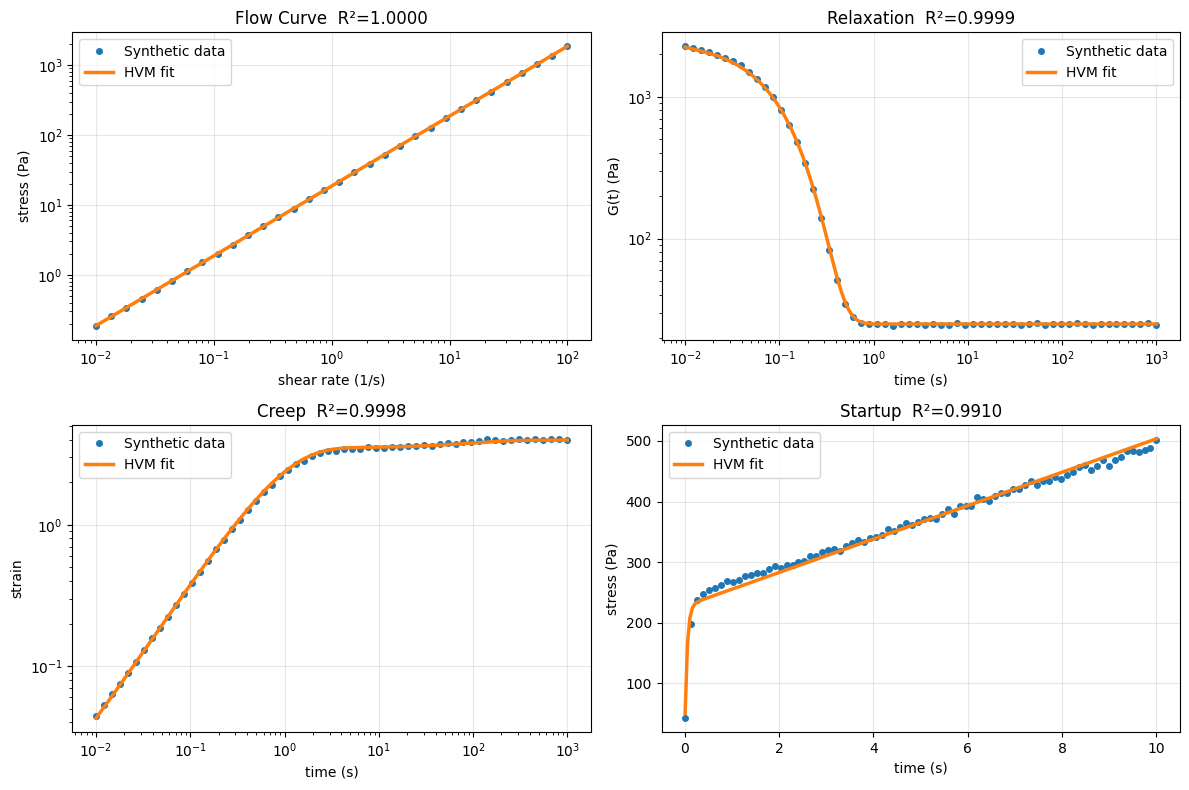

In [3]:
fig, axes = plt.subplots(2, 2, figsize=(12, 8))

for ax, (protocol, result) in zip(axes.ravel(), results.items(), strict=True):
    if protocol == "startup":
        ax.plot(result.x_data, result.y_data, "o", ms=4, label="Synthetic data")
        ax.plot(result.x_fit, result.y_fit, "-", lw=2.5, label="HVM fit")
        ax.set_xlabel("time (s)")
        ax.set_ylabel("stress (Pa)")
    else:
        ax.loglog(result.x_data, result.y_data, "o", ms=4, label="Synthetic data")
        ax.loglog(result.x_fit, result.y_fit, "-", lw=2.5, label="HVM fit")
        ax.set_xlabel("shear rate (1/s)" if protocol == "flow_curve" else "time (s)")
        ax.set_ylabel({
            "flow_curve": "stress (Pa)",
            "relaxation": "G(t) (Pa)",
            "creep": "strain",
        }[protocol])

    ax.set_title(f"{protocol.replace('_', ' ').title()}  R²={result.r_squared:.4f}")
    ax.grid(True, alpha=0.3)
    ax.legend()

fig.tight_layout()

## Inspect One Fitted Parameter Set

In [4]:
protocol = "relaxation"
model = results[protocol].fit_model

print(f"Fitted parameters for {protocol}:")
for name in model.parameters.keys():
    print(f"  {name:7s}: {model.parameters.get_value(name):.6g}")

Fitted parameters for relaxation:
  G_P    : 25.0408
  G_E    : 2434.16
  nu_0   : 8.07998e+07
  E_a    : 49993.6
  V_act  : 1e-05
  T      : 364.13
  G_D    : 12001.8
  k_d_D  : 599.999
